# AlgoSeek TAQ: Anatomy of a Market Crash

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Walk through tick-level AAPL TAQ data for March 16, 2020, the day the S&P 500 fell
about twelve percent in its worst session since 1987, and read what happens to the
microstructure observables under that stress: how often quotes update, how wide the
spread runs, how volume splits across venues, what sizes trade, and where the price
goes.

## Learning Objectives

After completing this notebook, you will be able to:
- Load nanosecond-precision AlgoSeek TAQ event streams via
  `load_nasdaq100_taq` and filter to regular trading hours.
- Quantify how quote update frequency, NBBO spread, and exchange-of-record
  distribution shift between the calm pre-crisis baseline and the March-16
  panic session.
- Distinguish trade events from NBBO updates within a single TAQ stream
  and explain why TAQ does not provide depth.

## Book reference

Section §3.2, *The Anatomy of Modern Market Data Feeds* — AlgoSeek TAQ
bullet points; §3.3 references this notebook (with `12_algoseek_taq_lob_reconstruction`)
for tick-level patterns during the March 2020 crash.

## Prerequisites

- AlgoSeek TAQ parquets under
  `data/equities/market/microstructure/algoseek_taq/` (download via the
  AlgoSeek loader; AAPL on 2020-03-16 is the focus day).

In [1]:
"""AlgoSeek TAQ: Anatomy of a Market Crash — tick-level microstructure exploration of AAPL on March 16, 2020."""

from datetime import time

import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_nasdaq100_taq
from utils.style import COLORS, show_plotly_with_alt


def rgba(color: str, alpha: float) -> str:
    """Translucent fill from an ML4T palette color (hex -> rgba string)."""
    h = COLORS[color].lstrip("#")
    r, g, b = (int(h[i : i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r}, {g}, {b}, {alpha})"

In [2]:
# Production defaults — Papermill injects overrides for CI

## 1. Loading the Data

We load AAPL for March 16, 2020 and immediately filter to regular trading
hours. Pre-market and after-hours data has thin liquidity and extreme spreads
that would distort our analysis.

In [3]:
SYMBOL = "AAPL"
DATE = "20200316"
DATE_ISO = f"{DATE[:4]}-{DATE[4:6]}-{DATE[6:]}"

# Regular trading hours (ET)
MARKET_OPEN = time(9, 30)
MARKET_CLOSE = time(16, 0)

# Load and filter to regular hours
taq_raw = load_nasdaq100_taq(symbols=[SYMBOL], start_date=DATE_ISO, end_date=DATE_ISO)

taq = taq_raw.filter(
    (pl.col("timestamp").dt.time() >= MARKET_OPEN) & (pl.col("timestamp").dt.time() <= MARKET_CLOSE)
)

print(f"=== {SYMBOL} on March 16, 2020 ===")
print(f"Raw events: {len(taq_raw):,}")
print(f"Regular hours: {len(taq):,} ({len(taq) / len(taq_raw) * 100:.1f}%)")

=== AAPL on March 16, 2020 ===
Raw events: 7,632,415
Regular hours: 7,425,510 (97.3%)


Most activity occurs during regular hours, but the pre/post-market events
we filtered out would create misleading outliers in our spread analysis.

The TAQ stream mixes trade prints with NBBO bid/ask updates. Counting each
event type shows where the information actually flows.

In [4]:
# Event type composition
event_counts = (
    taq.group_by("event_type")
    .len()
    .with_columns((pl.col("len") / pl.sum("len") * 100).alias("pct"))
    .sort("len", descending=True)
)

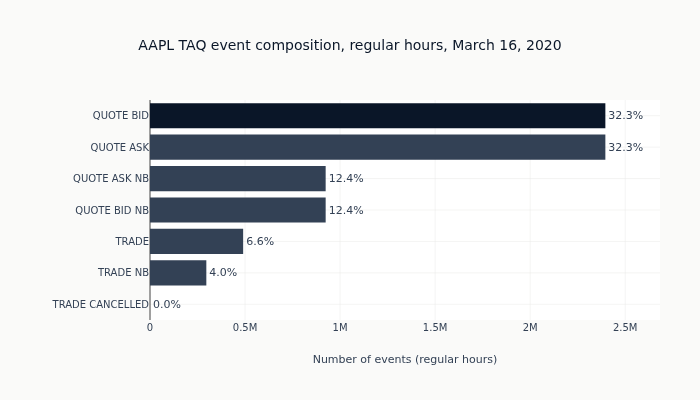

In [5]:
# Highlight the single busiest event type; keep the rest neutral.
top_event = event_counts["event_type"][0]
bar_colors = [
    COLORS["blue"] if e == top_event else COLORS["neutral"]
    for e in event_counts["event_type"].to_list()
]

fig = go.Figure(
    go.Bar(
        x=event_counts["len"].to_list(),
        y=event_counts["event_type"].to_list(),
        orientation="h",
        marker_color=bar_colors,
        text=[f"{p:.1f}%" for p in event_counts["pct"].to_list()],
        textposition="outside",
        cliponaxis=False,
    )
)
fig.update_layout(
    title=dict(text="AAPL TAQ event composition, regular hours, March 16, 2020"),
    xaxis_title="Number of events (regular hours)",
    xaxis=dict(range=[0, event_counts["len"].max() * 1.12]),
    yaxis=dict(categoryorder="total ascending"),
    height=400,
    margin=dict(l=150, r=40),
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "A horizontal bar chart counting the day's TAQ events by type over regular trading hours, sorted so the most numerous type is the longest bar, each labelled with its percentage. The horizontal axis is a plain count of events.",
)

**Key observation**: Quote updates outnumber trades by ~10:1. This reflects
how market makers continuously adjust their prices in response to order flow
and information - the quote stream is where price discovery really happens.
Trades are just the tip of the iceberg.

## 2. The Opening Chaos

March 16 gapped down at the open by enough to trip the first of the market-wide
circuit breakers, which halt trading across every US equity venue when the S&P 500
falls seven percent from the previous close. What follows is what the tape looks like
around that.

Two filters stand between the raw tape and anything worth plotting.

Condition code `80000002` marks a late-reported trade, and on this tape every one of
them carries the prior session's closing price rather than the price it traded at. A
late report is a real trade with an unusable price, so it is dropped rather than
corrected.

The price band is a second net under the first. It is set from where the symbol
actually traded that session, so it is specific to this symbol-day and would have to
be re-derived for another; what it catches is anything the condition codes missed.

In [6]:
trades = taq.filter(
    (pl.col("event_type") == "TRADE")
    & (pl.col("conditions") != "80000002")  # Exclude erroneous late-reported trades
    & (pl.col("price") >= 235)  # Exclude unreasonably low prices
    & (pl.col("price") <= 265)  # Exclude erroneous high prices ($277.97 prints)
)

# Aggregate by minute
minute_activity = (
    trades.with_columns(pl.col("timestamp").dt.truncate("1m").alias("minute"))
    .group_by("minute")
    .agg(
        pl.len().alias("trade_count"),
        pl.col("quantity").sum().alias("volume"),
        pl.col("price").mean().alias("vwap"),
    )
    .sort("minute")
)

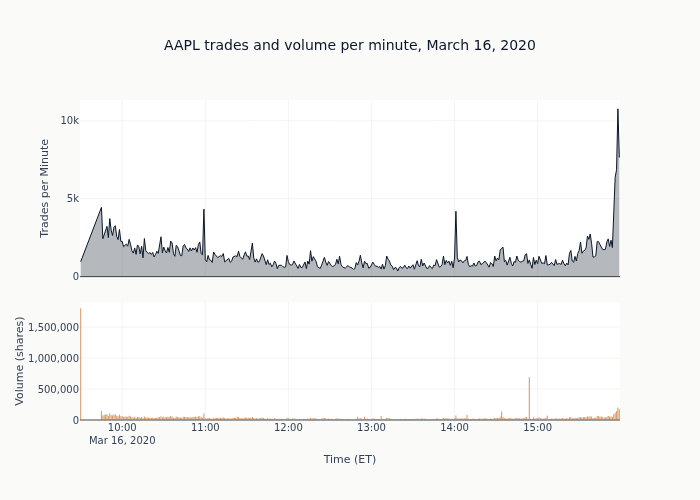

In [7]:
# Build intraday activity figure
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.6, 0.4],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(
        x=minute_activity["minute"].to_list(),
        y=minute_activity["trade_count"].to_list(),
        name="Trades/min",
        line=dict(color=COLORS["blue"], width=1),
        fill="tozeroy",
        fillcolor=rgba("blue", 0.3),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=minute_activity["minute"].to_list(),
        y=minute_activity["volume"].to_list(),
        name="Volume",
        marker_color=COLORS["copper"],
        opacity=0.7,
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(text=f"{SYMBOL} trades and volume per minute, March 16, 2020"),
    height=500,
    showlegend=False,
)
fig.update_yaxes(title_text="Trades per Minute", row=1, col=1)
fig.update_yaxes(title_text="Volume (shares)", tickformat=",", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

show_plotly_with_alt(
    fig,
    "Two stacked panels sharing a clock-time axis over the session. The upper counts trades in each minute, the lower sums the shares traded in the same minute.",
)

In [8]:
# Quantify the pattern
open_hour = minute_activity.filter(pl.col("minute").dt.hour() == 9)
midday = minute_activity.filter(pl.col("minute").dt.hour().is_between(11, 14))
close_hour = minute_activity.filter(pl.col("minute").dt.hour() == 15)

print("=== Trading Intensity by Period ===")
print(f"Opening hour (9:30-10:30):  {open_hour['trade_count'].mean():,.0f} trades/min avg")
print(f"Midday (11:00-14:00):       {midday['trade_count'].mean():,.0f} trades/min avg")
print(f"Closing hour (15:00-16:00): {close_hour['trade_count'].mean():,.0f} trades/min avg")

=== Trading Intensity by Period ===
Opening hour (9:30-10:30):  2,837 trades/min avg
Midday (11:00-14:00):       927 trades/min avg
Closing hour (15:00-16:00): 1,896 trades/min avg


**The U-shaped pattern is amplified**: On a normal day, we'd see 2-3x more
activity at open/close vs midday. On March 16, the opening spike is extreme -
pent-up overnight selling hitting the market all at once. The circuit breaker
halt (9:34-9:49 AM) is visible as the brief dip after the initial surge.

## 3. Spread Dynamics: The Cost of Panic

The bid-ask spread is the price of immediacy. During calm markets, AAPL
trades with a 1-2 cent spread (~1-2 bps). What happened on March 16?

The spread has to be measured on the consolidated quote, not on any one venue's. The
national best bid and offer is the highest bid and lowest ask across every US equity
venue at a moment, and it is what a marketable order actually meets - a single venue's
quote can be wide while the consolidated one is tight.

Zero-priced quotes are dropped: a venue with nothing resting on a side publishes a zero
rather than an absence, and treating that as a price would put the spread at hundreds
of dollars.

In [9]:
nbbo_quotes = (
    taq.filter(
        pl.col("event_type").str.contains("NB")  # Only NBBO quotes
        & (pl.col("price") > 0)  # Exclude zero-price quotes
    )
    .select(["timestamp", "event_type", "price"])
    .sort("timestamp")
)

# Pivot to get bid and ask columns, then forward-fill
nbbo_raw = (
    nbbo_quotes.with_columns(
        pl.when(pl.col("event_type") == "QUOTE BID NB").then(pl.col("price")).alias("bid"),
        pl.when(pl.col("event_type") == "QUOTE ASK NB").then(pl.col("price")).alias("ask"),
    )
    .select(["timestamp", "bid", "ask"])
    .with_columns(
        pl.col("bid").forward_fill(),
        pl.col("ask").forward_fill(),
    )
    .drop_nulls()  # Drop rows before we have both bid and ask
)

In [10]:
# Sample at 1-second intervals for visualization (take last value per second)
nbbo = (
    nbbo_raw.group_by_dynamic("timestamp", every="1s")
    .agg(
        pl.col("bid").last(),
        pl.col("ask").last(),
    )
    .with_columns(
        (pl.col("ask") - pl.col("bid")).alias("spread"),
        ((pl.col("ask") - pl.col("bid")) / ((pl.col("ask") + pl.col("bid")) / 2) * 10000).alias(
            "spread_bps"
        ),
        ((pl.col("bid") + pl.col("ask")) / 2).alias("midpoint"),
    )
    .filter(pl.col("spread") > 0)  # Remove crossed/locked quotes
    .filter(pl.col("spread_bps") < 500)  # Remove outliers (>5% spread is data error)
)

In [11]:
# Spread statistics
spread_stats = nbbo.select(
    pl.col("spread_bps").mean().alias("mean"),
    pl.col("spread_bps").median().alias("median"),
    pl.col("spread_bps").quantile(0.95).alias("p95"),
    pl.col("spread_bps").max().alias("max"),
)

print("=== Spread Statistics (Regular Hours) ===")
print(f"  Mean:   {spread_stats['mean'][0]:>6.1f} bps")
print(f"  Median: {spread_stats['median'][0]:>6.1f} bps")
print(f"  95th:   {spread_stats['p95'][0]:>6.1f} bps")
print(f"  Max:    {spread_stats['max'][0]:>6.1f} bps")

# Normal day comparison
print("\n  (Normal day median for AAPL: ~1-2 bps)")

=== Spread Statistics (Regular Hours) ===
  Mean:      3.1 bps
  Median:    2.4 bps
  95th:      7.6 bps
  Max:      44.9 bps

  (Normal day median for AAPL: ~1-2 bps)


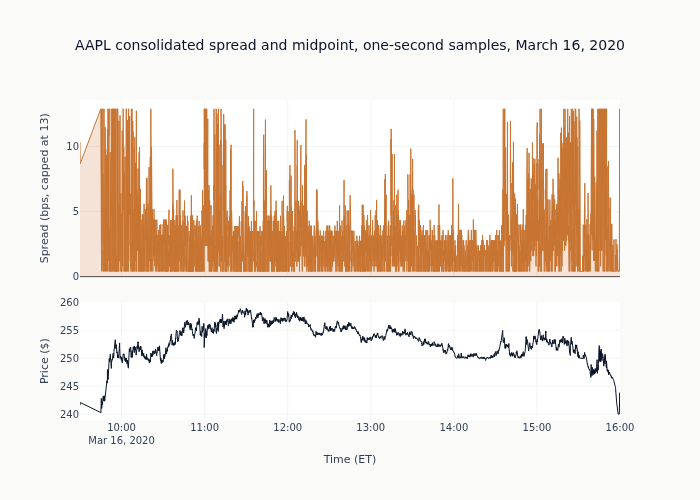

In [12]:
# Spread evolution figure
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.6, 0.4],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

spread_cap = nbbo["spread_bps"].quantile(0.99)

fig.add_trace(
    go.Scatter(
        x=nbbo["timestamp"].to_list(),
        y=nbbo["spread_bps"].clip(upper_bound=spread_cap).to_list(),
        name="Spread",
        line=dict(color=COLORS["copper"], width=1),
        fill="tozeroy",
        fillcolor=rgba("copper", 0.2),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=nbbo["timestamp"].to_list(),
        y=nbbo["midpoint"].to_list(),
        name="Midpoint",
        line=dict(color=COLORS["blue"], width=1),
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(
        text=f"{SYMBOL} consolidated spread and midpoint, one-second samples, March 16, 2020"
    ),
    height=500,
    showlegend=False,
)
fig.update_yaxes(title_text=f"Spread (bps, capped at {spread_cap:.0f})", row=1, col=1)
fig.update_yaxes(title_text="Price ($)", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

show_plotly_with_alt(
    fig,
    "Two stacked panels sharing a clock-time axis. The upper plots the consolidated bid-ask spread in basis points, sampled once a second and clipped at a stated cap so a few extreme seconds do not flatten the rest. The lower plots the quote midpoint in dollars over the same seconds.",
)

**What the spread tells us**:

- At the open, spreads spiked as market makers widened quotes to protect
  against adverse selection - they couldn't tell if the next trade was
  informed or noise
- The spread narrows through midday as volatility subsided and market makers
  regained confidence
- The median spread printed above is a multiple of what AAPL quotes on an ordinary
  session, which is the cost of trading rising with the uncertainty about what the
  next trade is worth
- Read the two panels against each other: where the price falls fastest is where the
  spread runs widest, which is the same mechanism seen from the other side

## 4. Exchange Fragmentation: Where Did Liquidity Go?

Modern equity markets are fragmented across 16+ exchanges and dozens of
dark pools. During stress, does liquidity concentrate or disperse?

In [13]:
# Exchange distribution
exchange_dist = (
    trades.group_by("exchange")
    .agg(
        pl.len().alias("trades"),
        pl.col("quantity").sum().alias("volume"),
    )
    .with_columns((pl.col("volume") / pl.sum("volume") * 100).alias("share"))
    .sort("volume", descending=True)
)

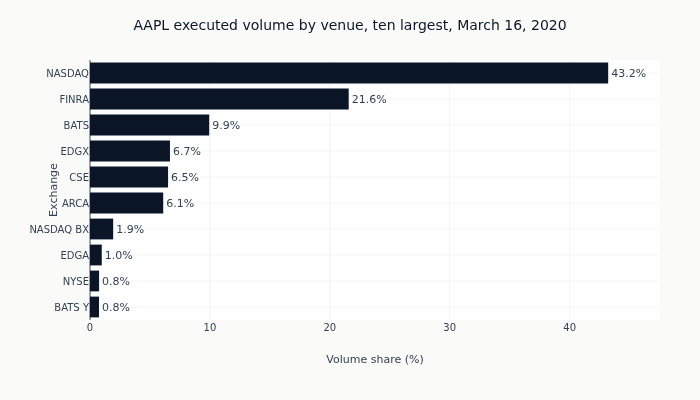

In [14]:
# Visualize top 10 exchanges
top_exchanges = exchange_dist.head(10)

fig = px.bar(
    top_exchanges.to_pandas(),
    y="exchange",
    x="share",
    orientation="h",
    text="share",
    color_discrete_sequence=[COLORS["blue"]],
)

fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside", cliponaxis=False)

fig.update_layout(
    title=dict(text=f"{SYMBOL} executed volume by venue, ten largest, March 16, 2020"),
    xaxis_title="Volume share (%)",
    xaxis=dict(range=[0, top_exchanges["share"].max() * 1.1]),
    yaxis_title="Exchange",
    yaxis=dict(categoryorder="total ascending"),
    height=400,
    margin=dict(l=90, r=40),
    showlegend=False,
)

show_plotly_with_alt(
    fig,
    "A horizontal bar chart of the ten venues with the largest share of executed volume, longest bar at the top, each labelled with its percentage. The horizontal axis is share of volume and the vertical axis names the venues.",
)

What to read off that chart, in the order it matters:

- **The listing exchange leads but does not dominate.** AAPL is listed on NASDAQ, and
  NASDAQ takes the largest single share - well short of a majority.
- **FINRA is not an exchange.** Its bar is the trade reporting facility, where
  off-exchange prints are recorded: dark pools and trades internalised by brokers. It
  is one line on the chart and many venues in reality.
- **The Cboe and NYSE families each span several bars.** BATS, EDGX, EDGA and BATS Y
  are one operator; NYSE, NYSE Arca and NYSE National are another. Read them grouped
  and the picture concentrates; read them as listed and it does not.

The practical consequence is that a quote from any one venue is a partial view. An
execution system that watches the listing exchange alone sees a fraction of the day's
liquidity, and that stays true under stress rather than breaking down under it.

## 5. Trade Size Distribution: Retail vs Institutional

Trade size reveals who's in the market. Small odd-lot trades (<100 shares)
often indicate retail; larger trades suggest institutional activity.

In [15]:
# Categorize trade sizes
size_categories = (
    trades.with_columns(
        pl.when(pl.col("quantity") < 100)
        .then(pl.lit("Odd lot (<100)"))
        .when(pl.col("quantity") <= 500)
        .then(pl.lit("Small (100-500)"))
        .when(pl.col("quantity") <= 2000)
        .then(pl.lit("Medium (501-2000)"))
        .otherwise(pl.lit("Large (>2000)"))
        .alias("category")
    )
    .group_by("category")
    .agg(
        pl.len().alias("count"),
        pl.col("quantity").sum().alias("volume"),
    )
    .with_columns(
        (pl.col("count") / pl.sum("count") * 100).alias("count_pct"),
        (pl.col("volume") / pl.sum("volume") * 100).alias("volume_pct"),
    )
)

# Order for display
order = ["Odd lot (<100)", "Small (100-500)", "Medium (501-2000)", "Large (>2000)"]
size_categories = size_categories.with_columns(pl.col("category").cast(pl.Enum(order))).sort(
    "category"
)

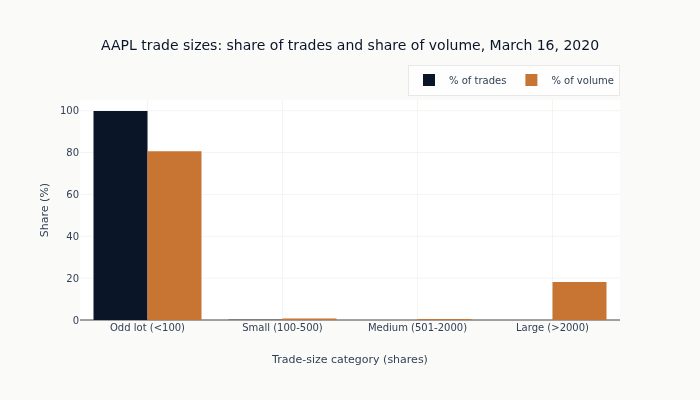

In [16]:
# Visualize the disconnect between trade count and volume
fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="% of trades",
        x=order,
        y=[size_categories.filter(pl.col("category") == c)["count_pct"][0] for c in order],
        marker_color=COLORS["blue"],
    )
)

fig.add_trace(
    go.Bar(
        name="% of volume",
        x=order,
        y=[size_categories.filter(pl.col("category") == c)["volume_pct"][0] for c in order],
        marker_color=COLORS["copper"],
    )
)

fig.update_layout(
    title=dict(text=f"{SYMBOL} trade sizes: share of trades and share of volume, March 16, 2020"),
    xaxis_title="Trade-size category (shares)",
    yaxis_title="Share (%)",
    barmode="group",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

show_plotly_with_alt(
    fig,
    "A grouped bar chart with one pair of bars per trade-size category. One bar in each pair is that category's share of the trade count and the other its share of volume, both as percentages, with the size categories in shares along the horizontal axis.",
)

The two bars at each size are the point of that chart, and the gap between them is
what a trade-count statistic hides. An odd lot is anything under a hundred shares, and
at a pre-split price in the hundreds of dollars a perfectly ordinary dollar amount buys
fewer than a hundred shares - so odd lots are not small trades in any economic sense.
They arrive from two directions at once: retail orders sized in dollars, and
institutional algorithms slicing a large order into pieces small enough not to move
the price.

At the other end, blocks are a negligible share of the trade count and a visible share
of the volume. Counting trades and counting shares rank the same day differently, and
a statistic that does not say which it counted is not interpretable.

## 6. The Day's Journey: Price Action

Finally, let's see how the price evolved throughout this historic day.

> **Note on prices**: AAPL split four for one on 31 August 2020, after this session.
> The tick data carries the prices as they were quoted at the time, so they are four
> times the split-adjusted series most historical databases return. Divide by four
> before comparing the two.

In [17]:
# Build 5-minute OHLCV bars from cleaned trade data
ohlcv = (
    trades.group_by_dynamic("timestamp", every="5m")
    .agg(
        pl.col("price").first().alias("open"),
        pl.col("price").max().alias("high"),
        pl.col("price").min().alias("low"),
        pl.col("price").last().alias("close"),
        pl.col("quantity").sum().alias("volume"),
        pl.len().alias("trade_count"),  # For sanity checking
    )
    .sort("timestamp")
    .filter(pl.col("trade_count") > 0)  # Remove empty bars
)

# Daily summary
day_open = ohlcv["open"][0]
day_high = ohlcv["high"].max()
day_low = ohlcv["low"].min()
day_close = ohlcv["close"][-1]
day_volume = ohlcv["volume"].sum()

print(f"=== {SYMBOL} - March 16, 2020 Summary ===")
print(f"  Open:   ${day_open:.2f}")
print(f"  High:   ${day_high:.2f}")
print(f"  Low:    ${day_low:.2f}")
print(f"  Close:  ${day_close:.2f}")
print(f"  Volume: {day_volume:,.0f} shares")
print(
    f"\n  Intraday range: ${day_high - day_low:.2f} ({(day_high - day_low) / day_open * 100:.1f}%)"
)
print(f"  Daily return:   {(day_close / day_open - 1) * 100:+.1f}%")

=== AAPL - March 16, 2020 Summary ===
  Open:   $241.83
  High:   $263.87
  Low:    $239.95
  Close:  $241.47
  Volume: 15,486,804 shares

  Intraday range: $23.91 (9.9%)
  Daily return:   -0.1%


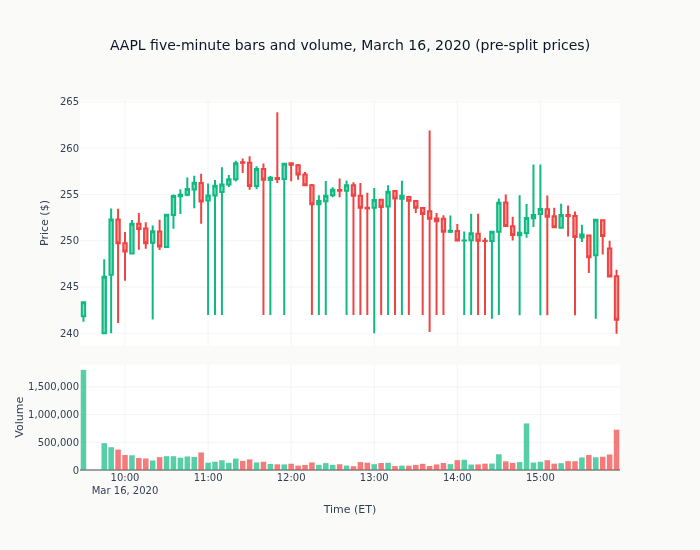

In [18]:
# Candlestick + volume built in one cell so both panels render together.
fig = make_subplots(
    rows=2,
    cols=1,
    row_heights=[0.7, 0.3],
    shared_xaxes=True,
    vertical_spacing=0.05,
)

fig.add_trace(
    go.Candlestick(
        x=ohlcv["timestamp"].to_list(),
        open=ohlcv["open"].to_list(),
        high=ohlcv["high"].to_list(),
        low=ohlcv["low"].to_list(),
        close=ohlcv["close"].to_list(),
        increasing_line_color=COLORS["positive"],
        decreasing_line_color=COLORS["negative"],
        name="OHLC",
    ),
    row=1,
    col=1,
)

colors = [
    COLORS["positive"] if c >= o else COLORS["negative"]
    for o, c in zip(ohlcv["open"].to_list(), ohlcv["close"].to_list(), strict=False)
]

fig.add_trace(
    go.Bar(
        x=ohlcv["timestamp"].to_list(),
        y=ohlcv["volume"].to_list(),
        marker_color=colors,
        opacity=0.7,
        name="Volume",
    ),
    row=2,
    col=1,
)

fig.update_layout(
    title=dict(text=f"{SYMBOL} five-minute bars and volume, March 16, 2020 (pre-split prices)"),
    xaxis_rangeslider_visible=False,
    height=550,
    showlegend=False,
)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Volume", tickformat=",", row=2, col=1)
fig.update_xaxes(title_text="Time (ET)", row=2, col=1)

show_plotly_with_alt(
    fig,
    "A candlestick chart of five-minute bars over the session in the upper panel and the shares traded in each bar in the lower panel, sharing a clock-time axis. Prices are as quoted at the time, before the later split.",
)

Four things to find on that chart, in time order:

- **The gap at the open.** The first bar is far below Friday's close; the fall
  happened overnight, not during the session.
- **A gap in the bars shortly after the open.** That is the market-wide circuit
  breaker: the S&P 500 fell seven percent and every US equity venue halted for fifteen
  minutes. No bar exists because no trading did.
- **A long middle.** Between the late morning and the early afternoon the bars settle
  into a range, with volume falling away from its opening level.
- **The close relative to the open.** Where the last bar sits against the first is what
  the day cost a buy-and-hold position, and it is not the same as how far the price
  travelled to get there.

That last distinction is the one worth carrying. The intraday range is a multiple of
what AAPL covers on an ordinary session, and a strategy that trades within the day is
exposed to the range rather than to the close-to-close move.

## Key Takeaways

**1. Most of the tape is quotes, not trades.** The event composition chart is the
first thing this notebook draws for that reason: an analysis built on the trade
stream alone discards the larger part of what the venue published, and price discovery
happens in the part it discarded.

**2. The spread is a price, and stress raises it.** Widening spreads are market makers
charging more to stand between buyers and sellers when they are less sure what the
next trade is worth. Read as an execution cost, that is the day getting more expensive
to trade, not just more volatile.

**3. Liquidity stays fragmented under stress.** The venue chart does not concentrate
when the market falls, so an execution system still has to look in many places at
once - and has to know which bars are exchanges and which are reporting facilities.

**4. Counting trades and counting shares rank a day differently.** Odd lots take
almost all the trade count and much less of the volume; blocks are the reverse. Any
statistic about trade sizes has to say which it counted.

**5. A price level is not a price series.** These are pre-split prices, four times the
adjusted series a database returns for the same day. Joining the two without adjusting
produces a four-fold jump that looks like an event.

### Known limitations

- One symbol on one exceptional day. Everything here describes March 16, 2020 for
  AAPL, and the point of choosing it is that it is not typical.
- Erroneous late-reported prints are excluded by condition code and by a price band.
  The band is set from what AAPL traded at that day, so it would need changing for
  another symbol or another session.
- Venue shares are of executed volume on this tape, and the reporting-facility line
  aggregates many off-exchange destinations into one bar.

## Next Steps

- **LOB Reconstruction**: [`12_algoseek_taq_lob_reconstruction`](12_algoseek_taq_lob_reconstruction.ipynb) - Build
  NBBO at each trade for Lee-Ready classification
- **Minute Bars**: [`13_algoseek_minute_bars_eda`](13_algoseek_minute_bars_eda.ipynb) - Pre-aggregated data
  for longer-horizon analysis